# Ch 13 Processing Sequences w/ RNNs and CNNs

RNNs - Recurrent Neural Nets

Good for future prediction of time series - or any sequences, like sentences, documents, audio

In [55]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Recurrent Neurons and Layers

We have only been doing forward neural nets, but we can also add connections going backward

Simplest example: a neuron that receives two inputs: one normal input $x_1$ and its last output $\hat y_0$

This is easily turned into a layer, now the layer gets the input vector and the last output vector.

You also need two sets of weights, one for inputs and one for the last time step's outputs. Notation: $w_x$ and $w_{\hat y}$ The whole layer is represented with W matrix

Recurrent Layer Output:
$$ \hat y_t = \phi (W_x^Tx_t+W_{\hat y}^T\hat y_{t-1}+b) $$

Outputs for a layer for all instances in a mini batch:
$$ \hat Y_t  = \phi (X_tW_x +\hat Y_{t-1} W_{\hat y}+b)$$

- Yhat_t is an n_instances_in_batch x n_neurons matrix containing the layer output at time t.
- X_t is an n_instances_in_batch x n_input_features matrix
- W_x is an n_input_features x n_neurons matrix
- W_yhat is an n_neurons x n_neurons matrix (weights for outputs of previous time step)
- b is the bias term

This makes Y_hat at time t a function of every single input prior to it

### Memory Cells

Any part of a neural net that preserves some state across time steps is called a memory cell. Recurrent neurons are memory cells, but they have a hard time with memory longer than like 10 steps.

A cells state at time step t is notated at h_(t) (h for hidden). It is some function of the current inputs and the last state: $h_t = f(x_t, h_{t-1})$


### Input and Output Sequences

An RNN can take a sequence of inputs and can produce a sequence of outputs. Or you could ignore the sequence and just take the last output if you care about one vector. Or you could look for a single value, like a sentiment score after a sequence of review text. This is equence to sequence, sequence to vector, sequence to value

There's also input to sequence, just feed the same input vector in over and over. This can be useful for image captioning.

Bottom left to top right: sequence-sequence, sequence-vector, vector-sequence, and encoder-decoder
![image.png](attachment:image.png)

An encoder-decoder is a sequence-to-vector network followed by a vector-to-sequence network (the encoder and the decoder). One use of this is translation: give a sentence in english, the network converts this to a vector of values, then takes those values and outputs a sequence in mandarin.

## Training RNNs

To train an RNN, you have to "unroll" it thru time and then use regular backprop. This is called backpropagation thru time.

Normal forward pass -> decide which outputs are used for the Yhat -> calculate loss with Y vs Yhat

Each weight and bias gradient gets updated multiple times before gradient descent (ie first by Yhat2, then Yhat3, and so on)

## Forecasting a Time Series

Using CTA data for forecasting n passengers on bus and rail tomorrow:

In [56]:
import pandas as pd
from pathlib import Path
path = Path("/content/drive/MyDrive/ColabNotebooks/CTA_Data.csv")
df = pd.read_csv(path, parse_dates=["service_date"])
df.columns = ["date", "day_type", "bus", "rail", "total"]
df = df.sort_values("date").set_index("date")
df = df.drop("total", axis=1)
df = df.drop_duplicates()
df["bus"] = df["bus"].apply(lambda x: x.replace(",", ""))
df["rail"] = df["rail"].apply(lambda x: x.replace(",", ""))
df["bus"] = pd.to_numeric(df["bus"], errors="coerce")
df["rail"] = pd.to_numeric(df["rail"], errors="coerce")

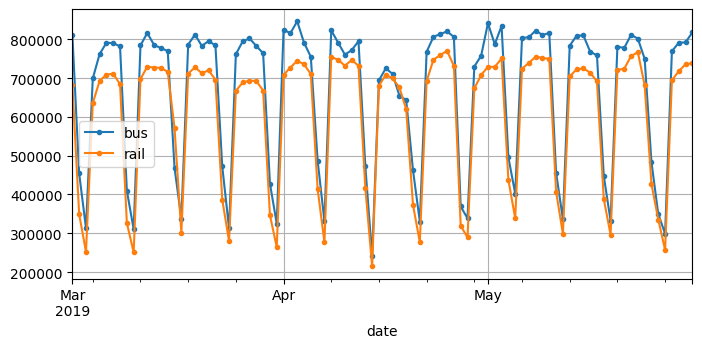

In [57]:
import matplotlib.pyplot as plt

df["2019-03":"2019-05"].plot(grid=True, marker=".", figsize=(8, 3.5))
plt.show()

Naive forecasting: use last weeks values to get this weeks. Works pretty well here, you can use differencing and find that the MAPE (mean average % error) is ~9% for both


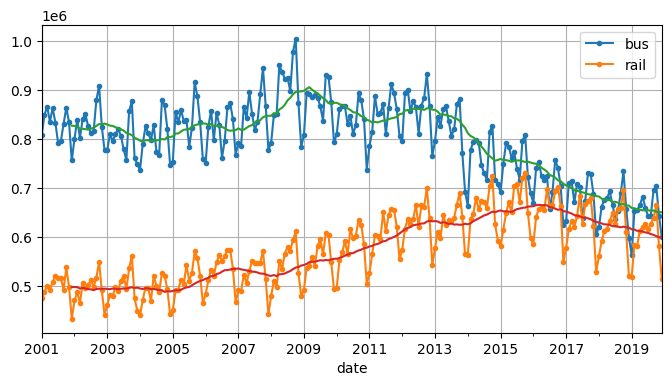

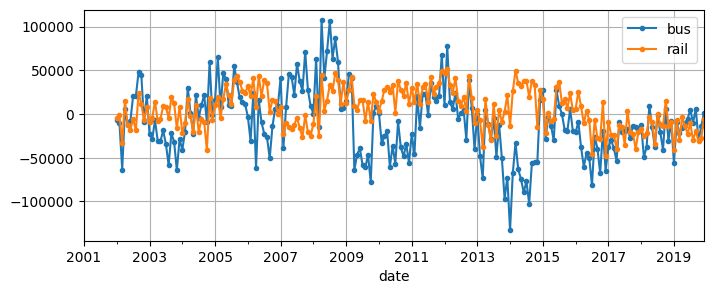

In [58]:
# checking for yrly seasonality

period = slice("2001", "2019")
df_monthly = df.select_dtypes(include="number").resample("ME").mean()
rolling_avg_12mo = df_monthly.loc[period].rolling(window=12).mean()

fig, ax = plt.subplots(figsize=(8, 4))
df_monthly[period].plot(ax=ax, marker=".")
rolling_avg_12mo.plot(ax=ax, grid=True, legend=False)
plt.show()

df_monthly.diff(12)[period].plot(grid=True, marker=".", figsize=(8, 3))
plt.show()

In [59]:
from statsmodels.tsa.arima.model import ARIMA

origin, today = "2019-01-01", "2019-05-31"
rail_series = df.loc[origin:today]["rail"].asfreq("D")
model = ARIMA(rail_series, order=(1,0,0), seasonal_order=(0,1,1,7))
model = model.fit()
model.forecast() - df.loc["2019-06-01"]["rail"]
# df.loc["2019-06-01"]["rail"]
# off by almost 49k, 13%

,0
2019-06-01,48714.626421


In [60]:
# Testing ARIMA
origin, start_date, end_date = "2019-01-01", "2019-03-01", "2019-05-31"
time_period = pd.date_range(start_date, end_date)
rail_series = df.loc[origin:end_date]["rail"].asfreq("D")
y_preds = []
for today in time_period.shift(-1):
    model = ARIMA(rail_series[origin:today],  # train on data up to "today"
                  order=(1, 0, 0),
                  seasonal_order=(0, 1, 1, 7))
    model = model.fit()  # note that we retrain the model every day!
    y_pred = model.forecast().iloc[0]
    y_preds.append(y_pred)

y_preds = pd.Series(y_preds, index=time_period)
mae = (y_preds - rail_series[time_period]).abs().mean()
mae
# This does better than naive forecasting by a large margin

np.float64(32040.720094289627)

### Preparing Data for ML Models

Two methods: naive and SARIMA.

In [61]:
# Geron's custom dataset to get time series data
import torch
class TimeSeriesDataset(torch.utils.data.Dataset):
    def __init__(self, series, window_length):
        self.series = series
        self.window_length = window_length

    def __len__(self):
        return len(self.series) - self.window_length

    def __getitem__(self, idx):
        if idx >= len(self):
            raise IndexError("dataset index out of range")
        end = idx + self.window_length  # 1st index after window
        window = self.series[idx : end]
        target = self.series[end]
        return window, target

In [62]:
# testing w/ 0,1,2,3,4,5
xt = torch.tensor([[0], [1], [2], [3], [4], [5]])
dataset = TimeSeriesDataset(xt, window_length=3)
for window, target in dataset:
  print(window, target)

tensor([[0],
        [1],
        [2]]) tensor([3])
tensor([[1],
        [2],
        [3]]) tensor([4])
tensor([[2],
        [3],
        [4]]) tensor([5])


In [63]:
from torch.utils.data import DataLoader
rail_train = torch.FloatTensor(df[["rail"]]["2016-01":"2018-12"].values / 1e6)
rail_valid = torch.FloatTensor(df[["rail"]]["2019-01":"2019-05"].values / 1e6)
rail_test = torch.FloatTensor(df[["rail"]]["2019-06":].values / 1e6)

window_length = 56 #8weeks
train_set = TimeSeriesDataset(rail_train, window_length)
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
valid_set = TimeSeriesDataset(rail_valid, window_length)
valid_loader = DataLoader(valid_set, batch_size=32)
test_set = TimeSeriesDataset(rail_test, window_length)
test_loader = DataLoader(test_set, batch_size=32)

### Linear Model Forecasting

In [64]:
import torch.nn as nn
#!pip install torchmetrics
import torchmetrics
device = "cuda"
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(window_length,1)
).to(device) # Changed: explicitly move model to 'device'

loss_fn = nn.HuberLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=.003, momentum=.9)
metric = torchmetrics.MeanAbsoluteError().to(device)

In [65]:
def train(model, data_loader, loss_fn, optimizer, metric, epochs):
    model.train()
    metrics = []
    for epoch in range(epochs):
      epoch_metrics = []
      for X_train, y_train in data_loader:
        X_train = X_train.to(device)
        y_train = y_train.to(device)
        y_pred = model(X_train)
        loss = loss_fn(y_pred, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_metrics.append(metric(y_pred, y_train).item())
      metrics.append(sum(epoch_metrics)/len(epoch_metrics))
    return metrics

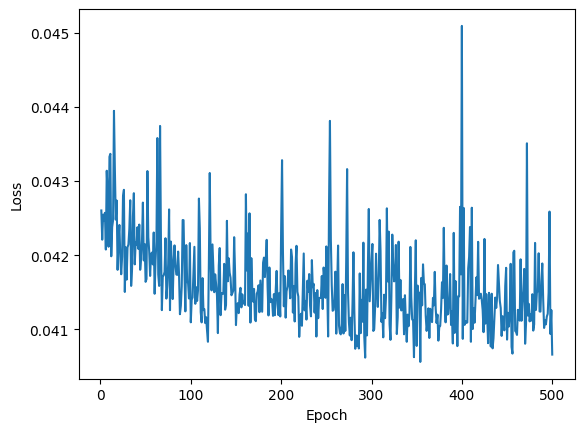

In [70]:
import numpy as np
losses = train(model, train_loader, loss_fn, optimizer, metric, 500)
plt.plot(np.arange(1,len(losses)+1), losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [67]:
def validate(model, data_loader, loss_fn, metric):
    model.eval()
    validation_losses = []
    validation_metrics = []
    with torch.no_grad():
        for X_val, y_val in data_loader:
            X_val = X_val.to(device)
            y_val = y_val.to(device)
            y_pred = model(X_val)
            loss = loss_fn(y_pred, y_val)
            validation_losses.append(loss.item())
            validation_metrics.append(metric(y_pred, y_val).item())
    return sum(validation_losses) / len(validation_losses), sum(validation_metrics) / len(validation_metrics)

In [71]:
val_loss, val_metric = validate(model, valid_loader, loss_fn, metric)
print(f"Validation Metric (MAE): {val_metric*1e6:.4f}")

Validation Metric (MAE): 37747.9618


### Forecasting with an RNN

In [85]:
class SimpleRNNModel(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    # hidden size is number of recurrent neurons
    # only predicting 1 val, which is output size
    super().__init__()
    self.hidden_size = hidden_size
    self.memory_cell = nn.Sequential(
        nn.Linear(input_size + hidden_size, hidden_size),
        nn.Tanh() #tends to be more stable
    )
    self.output = nn.Linear(hidden_size, output_size)

  def forward(self, X):
    # these are from the dataloader
    batch_size, window_length, dimensionality = X.shape
    Xt_first = X.transpose(0,1)
    # hidden state is initialized to zeroes
    H = torch.zeros(batch_size, self.hidden_size, device=X.device)
    for X_t in Xt_first:
      XH = torch.cat((X_t, H), dim=1)
      H = self.memory_cell(XH)
    # then for each time step we give the current inputs
    # and the hidden state to the memory cell
    # the memory cell gives us the new hidden state
    return self.output(H)

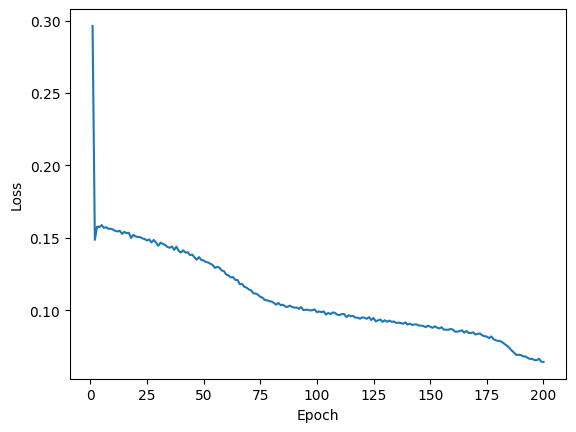

In [95]:
univariate_model = SimpleRNNModel(input_size=1, hidden_size=32, output_size=1)
univariate_model = univariate_model.to(device)
loss_fn = nn.HuberLoss()
optimizer = torch.optim.SGD(univariate_model.parameters(), lr=.003, momentum=.9) # Fixed: changed 'model.parameters()' to 'univariate_model.parameters()'
metric = torchmetrics.MeanAbsoluteError().to(device)
losses = train(univariate_model, train_loader, loss_fn, optimizer, metric, 200)
plt.plot(np.arange(1,len(losses)+1), losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()
# 200 epochs got down to 62000 MAE but the loss curve suggested
# we could keep going

In [96]:
val_loss, val_metric = validate(univariate_model, valid_loader, loss_fn, metric)
print(f"Validation Metric (MAE): {val_metric*1e6:.4f}")

Validation Metric (MAE): 62665.3060


You can build a similar version of this with PyTorch's nn.RNN module, which is way more optimized, but functionally the same, as the one above


### Forecasting with a Deep RNN

In PyTorch, you can add multiple layers to your RNN by setting num_layers hyperparam of nn.RNN

Beats out the single layer model by a small margin.

In [97]:
input_size = 1
hidden_size = 32
nn.RNN(input_size, hidden_size, num_layers=3, batch_first=True)

RNN(1, 32, num_layers=3, batch_first=True)

### Forecasting Multivariate Time Series

RNNs can easily be changed to do multivariate time series

In [100]:
multivar_data = df[["rail", "bus"]] / 1e6
multivar_data["next_day_type"] = df["day_type"].shift(-1)
multivar_data = pd.get_dummies(multivar_data, dtype=float)

mulvar_train = torch.FloatTensor(multivar_data["2016-01":"2018-12"].values / 1e6)
mulvar_valid = torch.FloatTensor(multivar_data["2019-01":"2019-05"].values / 1e6)
mulvar_test = torch.FloatTensor(multivar_data["2019-06":].values / 1e6)

class MulvarTimeSeriesDataset(TimeSeriesDataset):
  def __getitem__(self, idx):
    window, target = super().__getitem__(idx)
    return window, target[:1] #only want to predict rail for now

In [102]:
mulvar_train_set = MulvarTimeSeriesDataset(mulvar_train, window_length)
mv_train_loader = DataLoader(mulvar_train_set, batch_size=32, shuffle=True)

mulvar_valid_set = MulvarTimeSeriesDataset(mulvar_valid, window_length)
mv_mulvar_valid_set_loader = DataLoader(mulvar_valid_set, batch_size=32)

mulvar_test_set = MulvarTimeSeriesDataset(mulvar_test, window_length)
mv_test_loader = DataLoader(mulvar_test_set, batch_size=32)


In [103]:
# You give it 5 inputs instead of 1
mv_model = SimpleRNNModel(input_size=5, hidden_size=32, output_size=1)
mv_model = mv_model.to(device)
# This model massively improves MAE
# To add bus predictions, just change
  # return window, target[:2]
  # and output_size = 2

# Usually predicting a related value can help a model's performance,
# But in this case it degrades when you predict 2 values

### Forecasting Several Time Steps Ahead